# Consumers ETL

In [1]:
# libraries
import sys, os, glob
from pyspark.sql import SparkSession
import zipfile
import pandas as pd
from pyspark.sql.types import StructType, StructField, LongType, DoubleType, DateType, StringType, IntegerType
from pyspark.sql import functions as F
from pyspark.sql import Window
import matplotlib.pyplot as plt

In [2]:
sys.path.insert(0, "../scripts")
from spark_setup import get_spark
spark = get_spark()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/10 15:29:30 WARN Utils: Your hostname, tray, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/09/10 15:29:30 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/testing/utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
26/09/10 15:29:31 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
# Unzip the data files
zip_file_path = [
    "../data/project-2-bnpl-tables-part1.zip",
    "../data/project-2-bnpl-tables-part2.zip",
    "../data/project-2-bnpl-tables-part3.zip",
    "../data/project-2-bnpl-tables-part4.zip"
]

for zip_path in zip_file_path:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall("../data/")
    

In [4]:
# Read the data from the CSV and Parquet files into Spark DataFrames for the part 1
df_consumer_csv = pd.read_csv('../data/tables/consumer_fraud_probability.csv')
df_consumer_pq = spark.read.parquet('../data/tables/consumer_user_details.parquet')
df_tbl_consumer = pd.read_csv('../data/tables/tbl_consumer.csv', sep='|')

In [5]:
# function to display the first 5 rows of a dataframe
def display_first_5_rows(df):
    """
    Displays the first 5 rows of a Spark DataFrame.
    Parameters:
    df (DataFrame): The Spark DataFrame to display.
    """
    if isinstance(df, pd.DataFrame):
        print(df.head(5))
        print(f'Number of rows in the DataFrame: {len(df)}')
    else:
        df.show(5)
        print(f'Number of rows in the DataFrame: {df.count()}')

In [6]:
display_first_5_rows(df_consumer_csv)
display_first_5_rows(df_consumer_pq)
display_first_5_rows(df_tbl_consumer)

   user_id order_datetime  fraud_probability
0     6228     2021-12-19          97.629808
1    21419     2021-12-10          99.247380
2     5606     2021-10-17          84.058250
3     3101     2021-04-17          91.421921
4    22239     2021-10-19          94.703425
Number of rows in the DataFrame: 34864


+-------+-----------+
|user_id|consumer_id|
+-------+-----------+
|      1|    1195503|
|      2|     179208|
|      3|    1194530|
|      4|     154128|
|      5|     712975|
+-------+-----------+
only showing top 5 rows
Number of rows in the DataFrame: 499999
                name                        address state  postcode  gender  \
0   Yolanda Williams     413 Haney Gardens Apt. 742    WA      6935  Female   
1         Mary Smith                3764 Amber Oval   NSW      2782  Female   
2      Jill Jones MD             40693 Henry Greens    NT       862  Female   
3    Lindsay Jimenez      00653 Davenport Crossroad   NSW      2780  Female   
4  Rebecca Blanchard  9271 Michael Manors Suite 651    WA      6355  Female   

   consumer_id  
0      1195503  
1       179208  
2      1194530  
3       154128  
4       712975  
Number of rows in the DataFrame: 499999


Data about consumers:
- There are three data frames for consumers; one contains the user_id and customer_id, while the other one has information about the date on which each consumer made an order and the probability of being a fraud. The last one contains information about the consumer, such as name, address, state, postcode and gender.


In [7]:
df_consumer_csv.info()

<class 'pandas.DataFrame'>
RangeIndex: 34864 entries, 0 to 34863
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   user_id            34864 non-null  int64  
 1   order_datetime     34864 non-null  str    
 2   fraud_probability  34864 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


Order_datetime should be set as a date time dtype, not string.

In [8]:
df_tbl_consumer.info()

<class 'pandas.DataFrame'>
RangeIndex: 499999 entries, 0 to 499998
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   name         499999 non-null  str  
 1   address      499999 non-null  str  
 2   state        499999 non-null  str  
 3   postcode     499999 non-null  int64
 4   gender       499999 non-null  str  
 5   consumer_id  499999 non-null  int64
dtypes: int64(2), str(4)
memory usage: 43.9 MB


In [9]:
df_consumer_pq.printSchema()

root
 |-- user_id: long (nullable = true)
 |-- consumer_id: long (nullable = true)



# Schema

In [10]:
# Write schema

# schema for consumer with fraud probability
schema_fraud = StructType([
    StructField("user_id", LongType(), True),
    StructField("order_datetime", DateType(), True),
    StructField("fraud_probability", DoubleType(), True)
])

# Read the data from the CSV file into a Spark DataFrame with the defined schema
df_fraud_customers = spark.read.csv("../data/tables/consumer_fraud_probability.csv", schema=schema_fraud, header=True)

# schema for tbl_consumer 
schema_tbl_consumer = StructType([
    StructField("name", StringType(), True),
    StructField("address", StringType(), True),
    StructField("state", StringType(), True),
    StructField("postcode", IntegerType(), True),
    StructField("gender", StringType(), True),
    StructField("consumer_id", LongType(), True)
])

# Read the data from the CSV file into a Spark DataFrame with the defined schema
df_tbl_consumer = spark.read.csv("../data/tables/tbl_consumer.csv", schema=schema_tbl_consumer, header=True, sep='|')

# schema information user
schema_user_info = StructType([
    StructField("user_id", LongType(), True),
    StructField("consumer_id", LongType(), True)
])

# customer id information
df_user_info = spark.read.parquet('../data/tables/consumer_user_details.parquet', schema=schema_user_info)



In [11]:
df_fraud_customers.printSchema()

root
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)



The date of the order is now a date.

In [12]:
# write the new detaframes and store to the raw folder
df_fraud_customers.write.mode("overwrite").parquet("../data/raw/consumer_fraud_probability/")
df_tbl_consumer.write.mode("overwrite").parquet("../data/raw/tbl_consumer/")
df_user_info.write.mode("overwrite").parquet("../data/raw/consumer_user_details/")

In [13]:
df_fraud_customers = spark.read.parquet("../data/raw/consumer_fraud_probability/")
df_tbl_consumer = spark.read.parquet("../data/raw/tbl_consumer/")
df_user_info = spark.read.parquet("../data/raw/consumer_user_details/")

In [14]:
df_fraud_customers.printSchema()
df_tbl_consumer.printSchema()
df_user_info.printSchema()

root
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)

root
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- consumer_id: long (nullable = true)

root
 |-- user_id: long (nullable = true)
 |-- consumer_id: long (nullable = true)



Once we have the raw data with the proper schemas, we can proceed to curate the data.

In [15]:
# see features that are out of range.
df_fraud_customers.select(
    F.min("fraud_probability").alias("min_fraud_probability"),
    F.max("fraud_probability").alias("max_fraud_probability")
).show()

+---------------------+---------------------+
|min_fraud_probability|max_fraud_probability|
+---------------------+---------------------+
|    8.287143531552802|    99.24738020302328|
+---------------------+---------------------+



Probabilites are within the 0-100 range.

In [16]:
# check the range of order_datetime
df_fraud_customers.select(
    F.min("order_datetime").alias("date_min"),
    F.max("order_datetime").alias("date_max")
).show()

+----------+----------+
|  date_min|  date_max|
+----------+----------+
|2021-02-28|2022-02-27|
+----------+----------+



In [17]:
# dependencies
df_tbl_consumer.select("state").distinct().show()

+-----+
|state|
+-----+
|   NT|
|   SA|
|  VIC|
|  TAS|
|   WA|
|  NSW|
|  QLD|
|  ACT|
+-----+



There are no unexisten states and they all follow the same format.

In [18]:
# check the range of postcode based on state
# this is to verify dependencies
df_tbl_consumer.groupBy("state").agg(
    F.min("postcode").alias("min_postcode"),
    F.max("postcode").alias("max_postcode")
).show()

+-----+------------+------------+
|state|min_postcode|max_postcode|
+-----+------------+------------+
|   NT|         800|         909|
|   SA|        5000|        5950|
|  VIC|        3000|        9999|
|  TAS|        7000|        7470|
|   WA|        6000|        6997|
|  NSW|        1001|        4383|
|  QLD|        4000|        9726|
|  ACT|         200|        2914|
+-----+------------+------------+



We validated the postcode range using postcodes registered in the Postcodes & Postal Areas dataset from the Australian Bureau of Statistics; all states have postcodes within the appropriate range [1]. 

We identified that postcodes 9999 in VIC and 1001 in NSW are not within the range. However, these are postcodes that are used for Large Volume Receivers and Post Office Boxes. For this reason, we will maintain those values [2].

In [19]:
# look for postcode = 9999
df_tbl_consumer.filter(df_tbl_consumer.postcode == 9999).show()

+-----------------+--------------------+-----+--------+-----------+-----------+
|             name|             address|state|postcode|     gender|consumer_id|
+-----------------+--------------------+-----+--------+-----------+-----------+
|  Nicole Olsen MD|  54180 Amanda Locks|  VIC|    9999|Undisclosed|     189452|
|     Debra Wilson|7260 Smith Divide...|  VIC|    9999|     Female|    1374645|
|      Jean Parker|  5478 Aguilar Lodge|  VIC|    9999|     Female|     924794|
| Richard Anderson|190 Olson Heights...|  VIC|    9999|       Male|     729953|
|    Jamie Chapman|6398 Logan Run Su...|  VIC|    9999|     Female|     806203|
|     Stephen Kerr|649 Fisher Skyway...|  VIC|    9999|       Male|      81871|
|   Kimberly Davis|67119 Fernandez Club|  VIC|    9999|     Female|     982016|
|  Daniel Reynolds|060 Gibson Parkwa...|  VIC|    9999|       Male|     416262|
|Sharon Williamson|247 Medina Place ...|  VIC|    9999|     Female|     135340|
|Christopher Green|8853 Steven Ranch...|

In [20]:
df_tbl_consumer.filter(df_tbl_consumer.postcode == 9999).count()

149

In [21]:
# observe address
df_tbl_consumer.select("address").show(20, truncate=False)

# check the length of the address column
df_tbl_consumer.select(
    F.min(F.length("address")).alias("min_len"),
    F.max(F.length("address")).alias("max_len"),
    F.avg(F.length("address")).alias("avg_len")
).show()

+------------------------------+
|address                       |
+------------------------------+
|099 Mccoy Meadow Suite 931    |
|3545 Maldonado Spurs          |
|51833 Sherry Branch Suite 762 |
|698 Pena Roads Suite 975      |
|79762 Gabriela Route          |
|69919 Flores Valleys Suite 737|
|3784 Richard Island Suite 096 |
|684 Trevino Unions Apt. 181   |
|803 Smith Cliffs              |
|44463 Cooke Estate Suite 298  |
|452 Christopher Knoll         |
|843 Barajas Manors Apt. 495   |
|0378 Cooper Creek Apt. 961    |
|190 Mercado Overpass          |
|11956 Rodriguez Pass          |
|89496 Martin Lodge Apt. 485   |
|67131 Mata Well Apt. 366      |
|2322 Bush Passage             |
|52965 Wise Circle Suite 954   |
|8568 Carroll Via Apt. 680     |
+------------------------------+
only showing top 20 rows
+-------+-------+-----------------+
|min_len|max_len|          avg_len|
+-------+-------+-----------------+
|     10|     38|22.46253692507385|
+-------+-------+-----------------+



In [22]:
# check for address that is empty or null
df_tbl_consumer.filter(
    (F.trim(F.col("address")) == "") | F.col("address").isNull()
).count()

0

In [23]:
# adress with no number
df_tbl_consumer.filter(
    ~F.col("address").rlike(r"\d")
).show(20, truncate=False)

+----+-------+-----+--------+------+-----------+
|name|address|state|postcode|gender|consumer_id|
+----+-------+-----+--------+------+-----------+
+----+-------+-----+--------+------+-----------+



In [24]:
address_counts = df_tbl_consumer.groupBy("address").count() # count the number of occurrences of each address

address_counts.select(
    F.min("count").alias("min_count"),
    F.max("count").alias("max_count"),
    F.avg("count").alias("avg_count")
).show()

+---------+---------+------------------+
|min_count|max_count|         avg_count|
+---------+---------+------------------+
|        1|        3|1.0000880079207128|
+---------+---------+------------------+



Some customers appear more than once in the record, which may be because people live in the same place. Further analysis of duplicates is necessary.

In [25]:
n_rows = df_tbl_consumer.count() # count the number of rows in the dataframe
n_unique_ids = df_tbl_consumer.select("consumer_id").distinct().count() # count the number of unique consumer_id

print(f"Rows: {n_rows}")
print(f"Unique consumer_id: {n_unique_ids}")

Rows: 499999
Unique consumer_id: 499999


In [26]:
n_rows = df_user_info.count()
# count the number of unique user_id and consumer_id
n_unique_user = df_user_info.select("user_id").distinct().count()
n_unique_consumer = df_user_info.select("consumer_id").distinct().count()

print(f"Rows: {n_rows}")
print(f"Unique user_id: {n_unique_user}")

Rows: 499999
Unique user_id: 499999


In [27]:
n_rows = df_fraud_customers.count()
# count the number of unique combinations of user_id and order_datetime
n_unique_combo = df_fraud_customers.select("user_id", "order_datetime").distinct().count()

print(f"Rows: {n_rows}")
print(f"Unique combinations: {n_unique_combo}")

Rows: 34864
Unique combinations: 34765


In [28]:
# check duplicates, see if the fraud probability is the same
duplicates = df_fraud_customers.groupBy("user_id", "order_datetime") \
    .count() \
    .filter(F.col("count") > 1) \
    .select("user_id", "order_datetime")

df_fraud_customers.join(duplicates, on=["user_id", "order_datetime"], how="inner") \
    .orderBy("user_id", "order_datetime") \
    .count()

198

It seems that there are 198 duplicates. However, it can happen that users made an order on the same date. For that reason, we will flag these values and maintain them until we join the datasets.

In [29]:
window_spec = Window.partitionBy("user_id", "order_datetime")

df_fraud_customers = df_fraud_customers.withColumn(
    "is_same_day_duplicate",
    F.when(F.count('*').over(window_spec) > 1, True).otherwise(False)
)

df_fraud_customers.filter(F.col("is_same_day_duplicate") == True).count()

198

In [30]:
df_tbl_consumer.select("gender").distinct().show()

+-----------+
|     gender|
+-----------+
|     Female|
|Undisclosed|
|       Male|
+-----------+



# Outliers

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


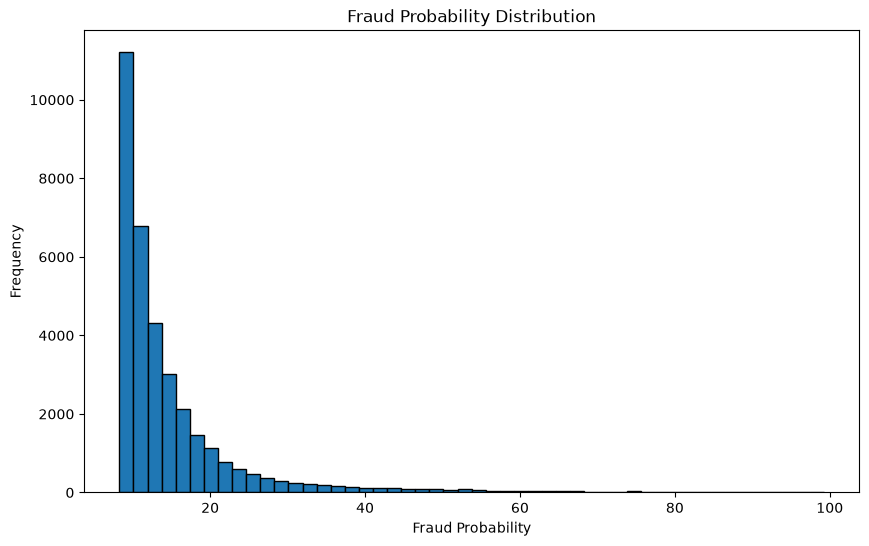

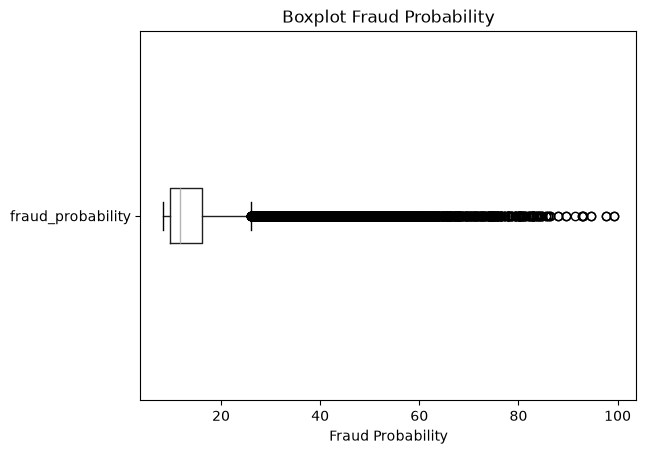

In [31]:
# check outliers in fraud_probability
pdf_fraud = df_fraud_customers.select("fraud_probability").toPandas()

plt.figure(figsize=(10, 6))
plt.hist(pdf_fraud["fraud_probability"], bins=50, edgecolor="black")
plt.xlabel("Fraud Probability")
plt.ylabel("Frequency")
plt.title("Fraud Probability Distribution")
plt.show()

pdf_fraud.boxplot(column="fraud_probability", vert=False, grid=False)
plt.xlabel("Fraud Probability")
plt.title("Boxplot Fraud Probability")
plt.show()

In [32]:
pdf_fraud["fraud_probability"].describe()

count    34864.000000
mean        15.120091
std          9.946085
min          8.287144
25%          9.634437
50%         11.735624
75%         16.216158
max         99.247380
Name: fraud_probability, dtype: float64

75% of the data have a fraud probability of 16%. In this case, we will maintain values with a high probability, since this can represent real cases where there was an actual probability of fraud, which is necessary for BNPL to flag these customers.

# Missing values

In [33]:
# verify if there are any null values in the dataframes
df_fraud_customers.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_fraud_customers.columns
]).show()

df_tbl_consumer.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_tbl_consumer.columns
]).show()

df_user_info.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_user_info.columns
]).show()

+-------+--------------+-----------------+---------------------+
|user_id|order_datetime|fraud_probability|is_same_day_duplicate|
+-------+--------------+-----------------+---------------------+
|      0|             0|                0|                    0|
+-------+--------------+-----------------+---------------------+

+----+-------+-----+--------+------+-----------+
|name|address|state|postcode|gender|consumer_id|
+----+-------+-----+--------+------+-----------+
|   0|      0|    0|       0|     0|          0|
+----+-------+-----+--------+------+-----------+

+-------+-----------+
|user_id|consumer_id|
+-------+-----------+
|      0|          0|
+-------+-----------+



There are no missing values in the dataframes.

In [34]:
# curated dataframes
df_fraud_customers.write.mode("overwrite").parquet("../data/curated/consumer_fraud_probability/")
df_tbl_consumer.write.mode("overwrite").parquet("../data/curated/tbl_consumer/")
df_user_info.write.mode("overwrite").parquet("../data/curated/consumer_user_details/")

# Multi-source

In [35]:
# load the curated dataframes
df_fraud_customers = spark.read.parquet("../data/curated/consumer_fraud_probability/")
df_tbl_consumer = spark.read.parquet("../data/curated/tbl_consumer/")
df_user_info = spark.read.parquet("../data/curated/consumer_user_details/")

user_id in df_user_info is a surrogate key, so we will join the tables with consumer_id.

In [36]:
# check for any conflict
fraud_ids = df_fraud_customers.select("user_id").distinct()
user_info_ids = df_user_info.select("consumer_id").distinct()
consumer_tbl_ids = df_tbl_consumer.select("consumer_id").distinct()

print("user_id in fraud:", fraud_ids.count())
print("consumer_id in user_info:", user_info_ids.count())
print("consumer_id in consumer_tbl:", consumer_tbl_ids.count())

user_id in fraud: 20128
consumer_id in user_info: 499999
consumer_id in consumer_tbl: 499999


In [37]:
fraud_ids.select(
    F.min("user_id").alias("user_min"),
    F.max("user_id").alias("user_max")
).show()

+--------+--------+
|user_min|user_max|
+--------+--------+
|       1|   24081|
+--------+--------+



In [38]:
df_tbl_consumer.select(
    F.min("consumer_id").alias("consumer_min"),
    F.max("consumer_id").alias("consumer_max")
).show()

+------------+------------+
|consumer_min|consumer_max|
+------------+------------+
|           4|     1499995|
+------------+------------+



In [39]:
df_user_info.select(
    F.min("user_id").alias("user_min"),
    F.max("user_id").alias("user_max")
).show()

+--------+--------+
|user_min|user_max|
+--------+--------+
|       1|  499999|
+--------+--------+



Some customers are registered but have no orders. Since we are looking to analyse the fraud probability and understand the customers who purchase items, we will perform an inner join, leaving aside those with no registration in df_fraud_customers.

In [40]:
# create inner join
df_cutomers = (
    df_fraud_customers
    .join(df_user_info, on="user_id", how="inner")
    .join(df_tbl_consumer, on="consumer_id", how="inner")
)

print("Rows in df_cutomers:", df_cutomers.count())

Rows in df_cutomers: 34864


In [41]:
df_cutomers.printSchema()
df_cutomers.show(5, truncate=False)

root
 |-- consumer_id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)

+-----------+-------+--------------+------------------+---------------------+-----------------+-----------------------------+-----+--------+------+
|consumer_id|user_id|order_datetime|fraud_probability |is_same_day_duplicate|name             |address                      |state|postcode|gender|
+-----------+-------+--------------+------------------+---------------------+-----------------+-----------------------------+-----+--------+------+
|712975     |5      |2021-10-04    |10.868364868449886|false                |Rebecca Blanchard|9271 Michael Manors Suite 651|WA   |635

In [42]:
df_cutomers.select([
    F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df_cutomers.columns
]).show()

+-----------+-------+--------------+-----------------+---------------------+----+-------+-----+--------+------+
|consumer_id|user_id|order_datetime|fraud_probability|is_same_day_duplicate|name|address|state|postcode|gender|
+-----------+-------+--------------+-----------------+---------------------+----+-------+-----+--------+------+
|          0|      0|             0|                0|                    0|   0|      0|    0|       0|     0|
+-----------+-------+--------------+-----------------+---------------------+----+-------+-----+--------+------+



In [43]:
df_cutomers.filter(F.col("is_same_day_duplicate") == True).count()

198

In [44]:
n_rows = df_cutomers.count()
n_distinct = df_cutomers.distinct().count()

print(f"Total rows: {n_rows}")
print(f"Distinct rows (considering all columns): {n_distinct}")

Total rows: 34864
Distinct rows (considering all columns): 34765


In [45]:
df_cutomers.groupBy("user_id", "order_datetime").count().filter(F.col("count") > 1).count()

99

The number of duplicates remaining is consistent with the values flagged as duplicates.

In [46]:
pdf_fraud = df_cutomers.select("fraud_probability").toPandas()

pdf_fraud["fraud_probability"].describe()

/home/sarah/miniforge3/lib/python3.13/site-packages/pyspark/sql/pandas/conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


count    34864.000000
mean        15.120091
std          9.946085
min          8.287144
25%          9.634437
50%         11.735624
75%         16.216158
max         99.247380
Name: fraud_probability, dtype: float64

Distribution is still the same as before.

In [47]:
# store the final curated dataframe for customers
df_cutomers.write.mode("overwrite").parquet("../data/curated/df_customers/")

In [48]:
spark.read.parquet("../data/curated/df_customers/").printSchema()
spark.read.parquet("../data/curated/df_customers/").count() 

root
 |-- consumer_id: long (nullable = true)
 |-- user_id: long (nullable = true)
 |-- order_datetime: date (nullable = true)
 |-- fraud_probability: double (nullable = true)
 |-- is_same_day_duplicate: boolean (nullable = true)
 |-- name: string (nullable = true)
 |-- address: string (nullable = true)
 |-- state: string (nullable = true)
 |-- postcode: integer (nullable = true)
 |-- gender: string (nullable = true)



34864

# References

[1] Australian Bureau of Statistics. "Postcodes & Postal Areas". Accessed Sep. 04, 2026. [Online]. Available: https://www.abs.gov.au/websitedbs/censushome.nsf/home/factsheetspoa?opendocument&navpos=450

[2] M. Proctor. "Download Free Database of Australian Postcodes". Accessed Sep. 04, 2026. [Online]. Available: https://www.matthewproctor.com/australian_postcodes